# QC testing: Setting Hard QC thresholds

+ Plate 1: 96 samples(60/36), on MEGA kit v2, seq 15 sub-lib X 3 runs
+ Plate 2: 96 samples (88/8), on MEGA kit v2, seq 16 sub-lib X 3 runs
+ ~30 Billion reads per plate
+ Parse workflow has a low [doublet rate](https://support.parsebiosciences.com/hc/en-us/articles/360053107311-What-is-the-expected-doublet-rate#:~:text=Doublet%20rates%20are%20low%2C%20less,through%20the%20Whole%20Transcriptome%20workflow.): ~3% per 100K cells

***

Testing different filtering thresholds:

- Filter 1: Hard threshold for genes
    - min_genes_per_cell=500, 
    - max_genes_per_cell=6000,
    - min_counts_per_cell=500, 
    - min_cells_per_gene=5, 
    - min_cells_per_sample=10
    - Mito - 5%
    - Ribo - 5%
    - Filtering MT genes and MALAT1 removed
    - rm_doublets = False
    - rm_mad_outliers = False
- Filter 2: MAD thresholds per sample and doublet removal
    - Done in initial QC run
- Filter 3: Retain genes with at least `min_reads` in at least `min_samples` in the dataset
    - Discussed 100 samples, but indivdual plates have < 100 samples so applied n samples
 
***

In [1]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [2]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5]
batch_col = 'plate' # Should we set to plate and sample??
rm_doublets = False
rm_mad_outliers = False
run_filter_1 = True
run_filter_2 = False
run_filter_3 = False

# Load data

2025-01-14 13:49:17,133 - INFO - Plate variable detected: plate1
2025-01-14 13:49:17,134 - INFO - Processing plate: plate1



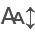

2025-01-14 13:49:17,153 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-14 13:49:17,154 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-14 13:49:17,155 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-14 13:49:17,156 - INFO - Scanpy directory exists: True
2025-01-14 13:49:17,157 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-14 13:49:17,158 - INFO - Loading data ...


Processing 1 plate(s) with downsampling to 4000 cells per plate.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad ...
Plate 1 dimensions: (861960, 65472)
Plate 1 matrix dimensions: (861960, 65472)
Only one plate processed; no need to find common genes.
AnnData object with n_obs × n_vars = 4000 × 65472
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden'
    var: 'gene_id', 'gene_name', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'norm10k'
    obsp: 'connectivities', 'distances'


In [3]:
# Initialize the environment and get all paths and logger
logger, root_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")

# Use the plate_path and scanpy_dir as needed
adata = load_and_dwnsmpl_data(None, plate_path)

In [4]:
adata.obs

sample species  gene_count  tscp_count  \
bc_wells                                                             
plate1_91_57_03__s15    18190_Thal    hg38        2000        3488   
plate1_48_02_81__s13  sample_12570    hg38        3775        9796   
plate1_36_17_33__s5   sample_18048    hg38        1966        2920   
plate1_56_92_48__s5   sample_12993    hg38        1419        2217   
plate1_58_15_50__s4   sample_11396    hg38        2814        5542   
...                            ...     ...         ...         ...   
plate1_43_14_47__s5   sample_14746    hg38        1622        2615   
plate1_94_88_10__s2     18351_Hipp    hg38        1916        3124   
plate1_90_01_95__s7       18190_FC    hg38         884        1260   
plate1_90_30_50__s10      18190_FC    hg38        1021        1658   
plate1_18_29_18__s3     14510_Thal    hg38        1120        1509   

                      mread_count leiden  
bc_wells                                  
plate1_91_57_03__s15         7084      5  
plate1_48_02_81__s13        19145     18  
plate1_36_17_33__s5          6782      8  
plate1_56_92_48__s5          5368      4  
plate1_58_15_50__s4         11161      8  
...                           ...    ...  
plate1_43_14_47__s5          6105     11  
plate1_94_88_10__s2          8559     19  
plate1_90_01_95__s7          2459      2  
plate1_90_30_50__s10         3466      2  
plate1_18_29_18__s3          2944      8  

[4000 rows x 6 columns]

# QC metadata

In [5]:
logger.info("Running QC ...")
adata.obs['sample'] = adata.obs['sample'].str.replace('sample_', '')
adata = adata[~adata.obs['sample'].str.endswith(tuple(['WGE', 'Hipp', 'Thal']))]
adata.obs['sublibrary'] = [x[1] for x in adata.obs.index.str.split('__s')] 
adata.obs['sample'].value_counts() # Cells per sample pre-filter

2025-01-14 13:50:56,491 - INFO - Running QC ...


sample
11654       114
18372       103
17048        96
17936        78
17486        74
           ... 
12047        25
14521        13
14402        10
14611_FC      9
17940         8
Name: count, Length: 73, dtype: int64

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

#plt.hist(adata.var['n_cells_by_counts'], bins=500)
#plt.xlabel('N cells expressing > 0')
#plt.ylabel('log(N genes)') # for visual clarity
#plt.axvline(2, color='red')
#plt.yscale('log') 

#sns.jointplot(
#   data=adata.obs,
#   x="log1p_total_counts",
#   y="log1p_n_genes_by_counts",
#   kind="hex",
#)
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate1_48_02_81__s13     12570    hg38        3775        9796        19145   
plate1_36_17_33__s5      18048    hg38        1966        2920         6782   
plate1_56_92_48__s5      12993    hg38        1419        2217         5368   
plate1_58_15_50__s4      11396    hg38        2814        5542        11161   
plate1_45_42_09__s15     17053    hg38        3660        8461        18013   
...                        ...     ...         ...         ...          ...   
plate1_50_53_82__s10     15611    hg38        1218        1702         3485   
plate1_40_59_24__s14     11449    hg38        3752        9397        22165   
plate1_43_14_47__s5      14746    hg38        1622        2615         6105   
plate1_90_01_95__s7   18190_FC    hg38         884        1260         2459   
plate1_90_30_50__s10  18190_FC    hg38        1021        1658         3466   

                     leiden sublibrary  n_genes_by_counts  \
bc_wells                                                    
plate1_48_02_81__s13     18         13               3775   
plate1_36_17_33__s5       8          5               1966   
plate1_56_92_48__s5       4          5               1419   
plate1_58_15_50__s4       8          4               2814   
plate1_45_42_09__s15     10         15               3660   
...                     ...        ...                ...   
plate1_50_53_82__s10      0         10               1218   
plate1_40_59_24__s14     10         14               3752   
plate1_43_14_47__s5      11          5               1622   
plate1_90_01_95__s7       2          7                884   
plate1_90_30_50__s10      2         10               1021   

                      log1p_n_genes_by_counts  total_counts  ...  \
bc_wells                                                     ...   
plate1_48_02_81__s13                 8.236421   7719.541839  ...   
plate1_36_17_33__s5                  7.584265   6731.016522  ...   
plate1_56_92_48__s5                  7.258412   4921.387380  ...   
plate1_58_15_50__s4                  7.942718   7642.839872  ...   
plate1_45_42_09__s15                 8.205492   7879.303753  ...   
...                                       ...           ...  ...   
plate1_50_53_82__s10                 7.105786   4379.194583  ...   
plate1_40_59_24__s14                 8.230311   7926.100211  ...   
plate1_43_14_47__s5                  7.392032   5266.897272  ...   
plate1_90_01_95__s7                  6.785588   3424.818661  ...   
plate1_90_30_50__s10                 6.929517   3539.915041  ...   

                      pct_counts_in_top_500_genes  total_counts_mt  \
bc_wells                                                             
plate1_48_02_81__s13                    30.660362         2.116328   
plate1_36_17_33__s5                     48.663647         4.720110   
plate1_56_92_48__s5                     56.598685         1.803130   
plate1_58_15_50__s4                     39.363485         0.000000   
plate1_45_42_09__s15                    32.044732         0.000000   
...                                           ...              ...   
plate1_50_53_82__s10                    60.886721         0.000000   
plate1_40_59_24__s14                    31.677483         0.000000   
plate1_43_14_47__s5                     52.036633         0.000000   
plate1_90_01_95__s7                     73.472784         3.392718   
plate1_90_30_50__s10                    66.447833         0.000000   

                      log1p_total_counts_mt  pct_counts_mt  total_counts_ribo  \
bc_wells                                                                        
plate1_48_02_81__s13               1.136656       0.027415          39.509867   
plate1_36_17_33__s5                1.743988       0.070125           8.261028   
plate1_56_92_48__s5                1.030737       0.036639           8.528317   
p

In [7]:
adata.obs[['tscp_count', 'total_counts']] # Why the discrepancy? Duplicates? This is the filtered matrix??!!

tscp_count  total_counts
bc_wells                                      
plate1_48_02_81__s13        9796   7719.541839
plate1_36_17_33__s5         2920   6731.016522
plate1_56_92_48__s5         2217   4921.387380
plate1_58_15_50__s4         5542   7642.839872
plate1_45_42_09__s15        8461   7879.303753
...                          ...           ...
plate1_50_53_82__s10        1702   4379.194583
plate1_40_59_24__s14        9397   7926.100211
plate1_43_14_47__s5         2615   5266.897272
plate1_90_01_95__s7         1260   3424.818661
plate1_90_30_50__s10        1658   3539.915041

[3127 rows x 2 columns]

2025-01-14 13:50:57,355 - INFO - Most exp genes ...


normalizing counts per cell
    finished (0:00:00)


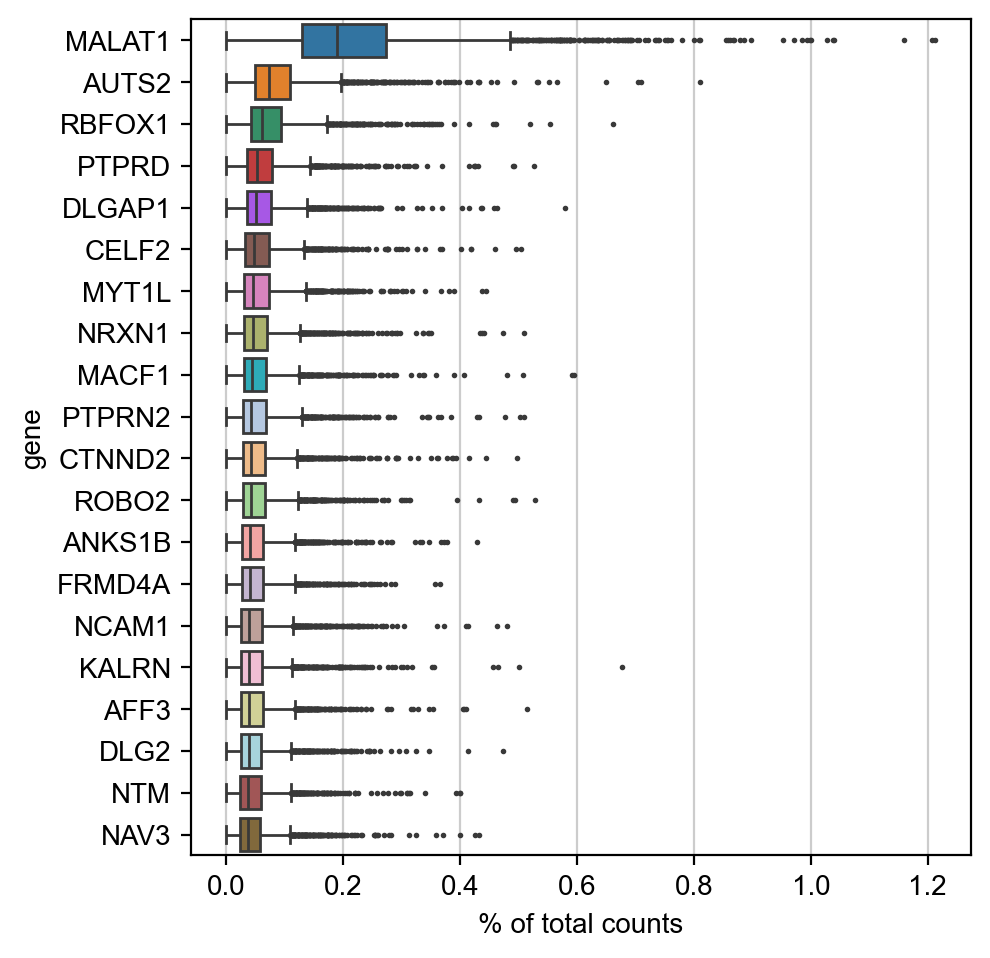

In [8]:
# Most expressed genes - Not such a big deal now?
logger.info("Most exp genes ...")
sc.pl.highest_expr_genes(adata, n_top=20)

In [9]:
# Filter 1
# - Remove cells with < 300 genes OR < 500 reads
# - Remove genes expressed in < 5 cells
# - Remove samples with fewer than 500 cells

#### NOTE: tscp_count != total_counts. Scanpy uses total_counts for filters. Check why these values don't match ####

2025-01-14 13:50:57,950 - INFO - Applying filter 1 ...
... storing 'sample' as categorical
... storing 'sublibrary' as categorical


Dimensions before applying filter: (3127, 65472)
filtered out 261 cells that have less than 500 genes expressed
filtered out 276 cells that have more than 6000 genes expressed
filtered out 40025 genes that are detected in less than 5 cells
filtered out 3 samples with < 10 cells.
Dimensions after applying filter: (2568, 25447)


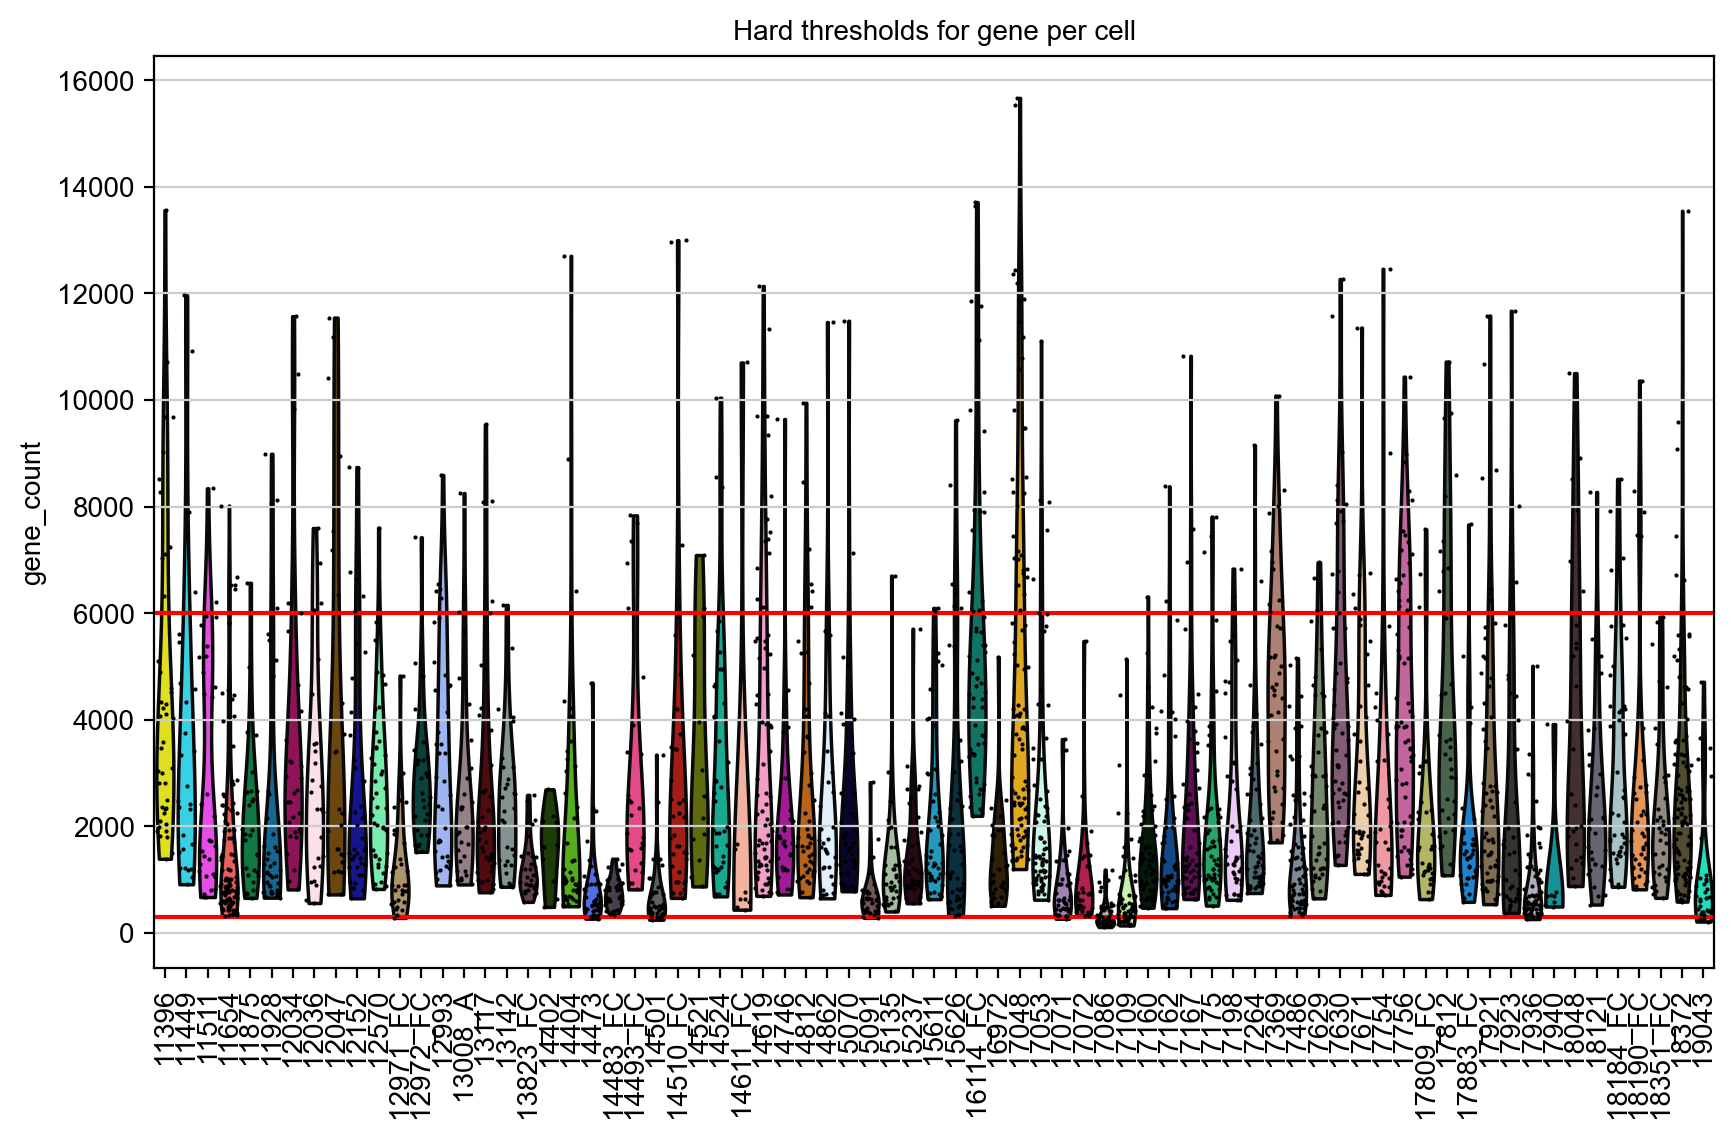

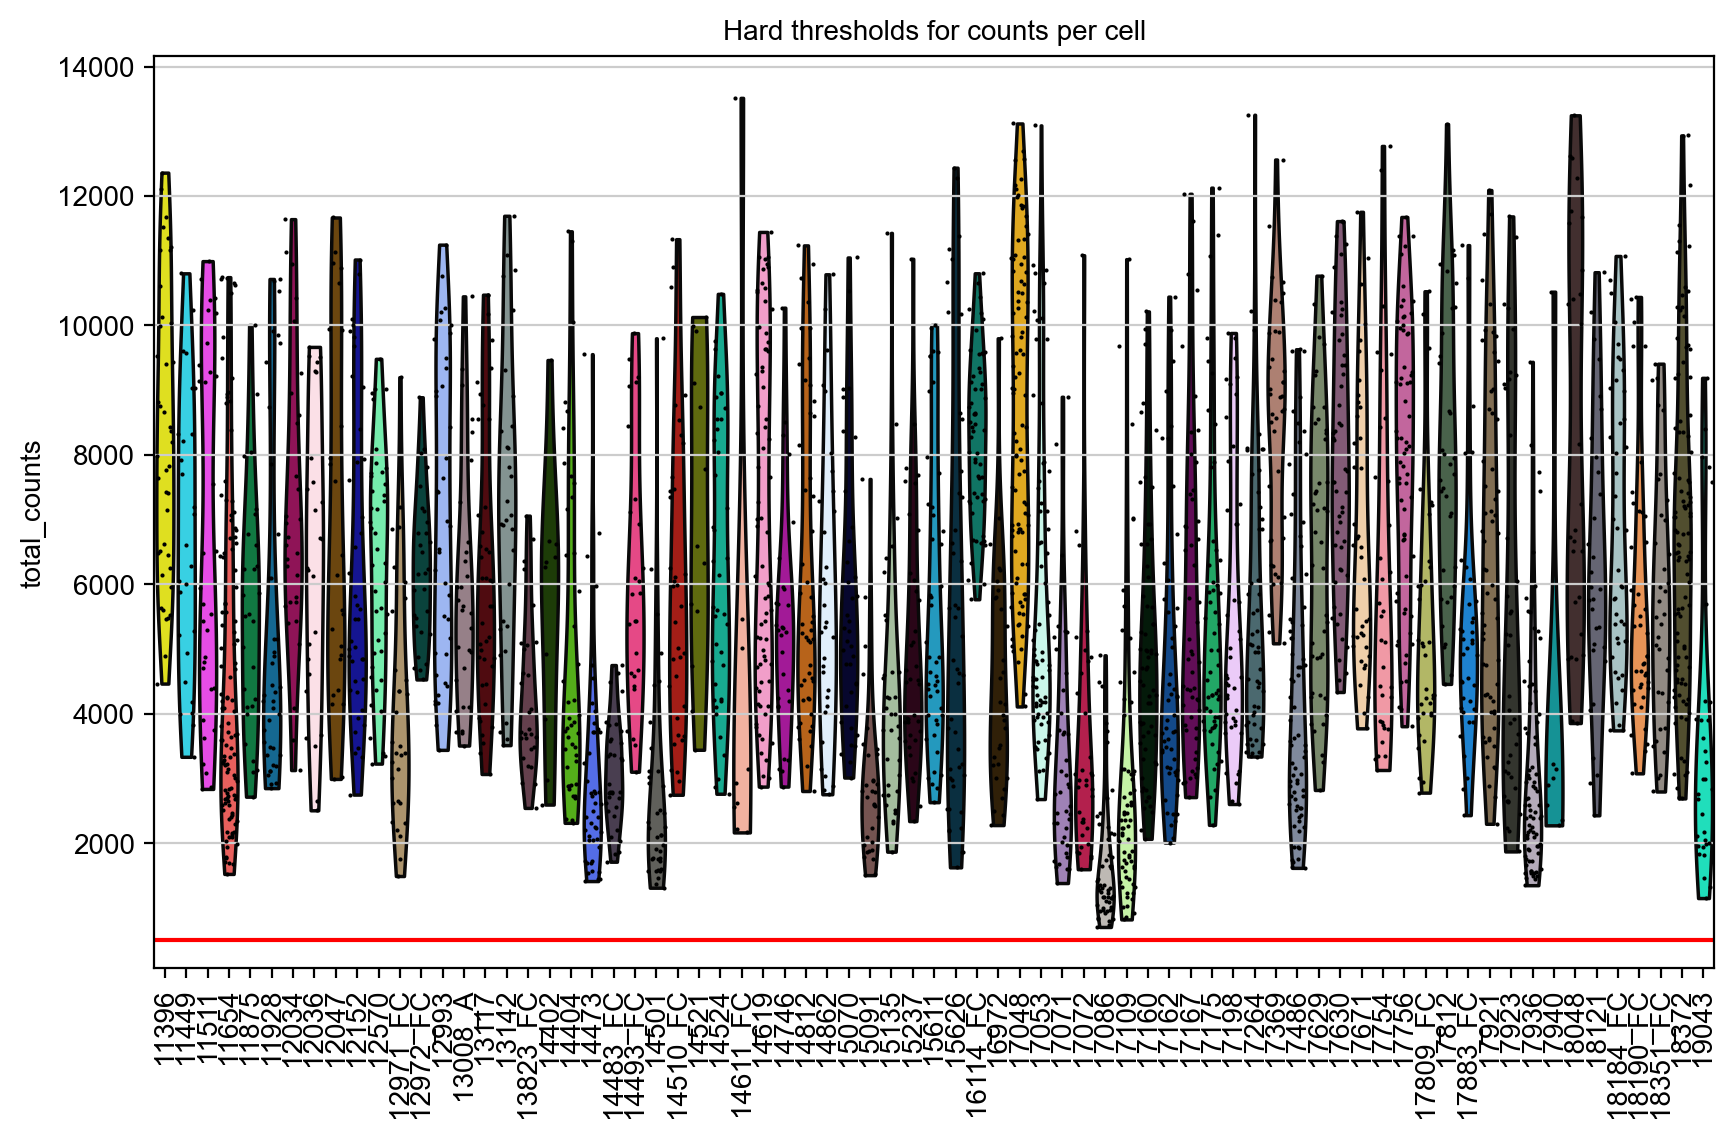

In [10]:
if run_filter_1 is True:
    logger.info("Applying filter 1 ...")

    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='gene_count',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for gene per cell')
    plt.axhline(y = 300, color = 'r', linestyle = '-')
    plt.axhline(y = 6000, color = 'r', linestyle = '-') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for counts per cell')
    plt.axhline(y = 500, color = 'r', linestyle = '-')
    
    # 
    
    filter_anndata(
        adata, 
        min_genes_per_cell=500, 
        max_genes_per_cell=6000,
        min_counts_per_cell=500, 
        min_cells_per_gene=5, 
        min_cells_per_sample=10)
    adata.shape

In [11]:
#Filter 2 
if run_filter_2 is True:
    logger.info("Detecting MAD outliers ...")
    detect_mad_outliers_per_sample(
        adata,
        group_column="sample",       # Column in `adata.obs` to group by
        target_column="total_counts",  # Column to detect outliers
        threshold=3,                # Number of MADs for outlier detection
        log=False,                  # Whether to log-transform the data
        use_median=True             # Use median and MAD (or mean and SD)
    )
    
    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    
    # Overlay outlier cells with red dots
    outliers = adata.obs.loc[adata.obs['mad_outlier']]
    ax.scatter(
        x=outliers['sample'],  # X-coordinates (groupby value)
        y=outliers['total_counts'],  # Y-coordinates (outlier values)
        color='red',
        label='Outliers',
        s=10,
        alpha=0.8
    )


In [12]:
# Note this function includes mito and ribo gene removal so is always run
logger.info("Applying filter 2 ...") 
filter_cells_and_genes(adata, 5, 5, rm_doublets, rm_mad_outliers)

2025-01-14 13:51:03,419 - INFO - Applying filter 2 ...


Applying cell filters with thresholds: mito > 5%, ribo > 5%
Counts of outliers for removal:
  mito_gt_threshold: 0
  ribo_gt_threshold: 0
  is_outlier: 0
Dimensions before cell filter: (2568, 25447)
Dimensions after cell filter: (2568, 25447)
Applying gene filters: remove mitochondrial genes and MALAT1
Number of genes removed: 14
Dimensions after gene filter: (2568, 25433)


In [13]:
# Filter 3
if run_filter_3 is True:
    sample_num = adata.obs['sample'].nunique() # Note that the maximum number of samples will be < 100 per plate
    def filter_genes_by_read_count(adata, min_reads=10, min_samples=100, inplace=True):
        """
        Identifies genes with at least `min_reads` in at least `min_samples` in the dataset.
        
        Parameters:
        - adata: AnnData object containing gene expression data.
        - min_reads: Minimum number of reads required per cell/sample.
        - min_samples: Minimum number of samples/cells that must meet the `min_reads` threshold.
        - inplace: If True, filters genes directly in `adata`. If False, returns a mask.
    
        Returns:
        - If `inplace=True`: Modifies `adata` by retaining only the filtered genes.
        - If `inplace=False`: Returns a boolean mask of the genes that meet the criteria.
        """
        # Count the number of samples with at least `min_reads` for each gene
        gene_mask = (adata.X >= min_reads).sum(axis=0).A1 >= min_samples
    
        if inplace:
            # Subset the AnnData object to retain only the filtered genes
            adata._inplace_subset_var(gene_mask)
        else:
            # Return the mask for external usage
            return gene_mask
    
    filter_genes_by_read_count(adata, min_reads=10, min_samples=100)
    print(f"Filtered genes: {adata.n_vars} remain.")
    
    #gene_mask = filter_genes_by_read_count(adata, min_reads=10, min_samples=sample_num, inplace=False)
    #print(f"Number of genes meeting criteria: {gene_mask.sum()}")
    
    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='gene_count',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for gene per cell')
    plt.axhline(y = 300, color = 'r', linestyle = '-')
    plt.axhline(y = 6000, color = 'r', linestyle = '-') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for counts per cell')
    plt.axhline(y = 500, color = 'r', linestyle = '-')


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
computing neighbors
        initialized `.distances` `.connectivities` 
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:00)
    computed connectivities (0:00:04)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
running Leiden clus

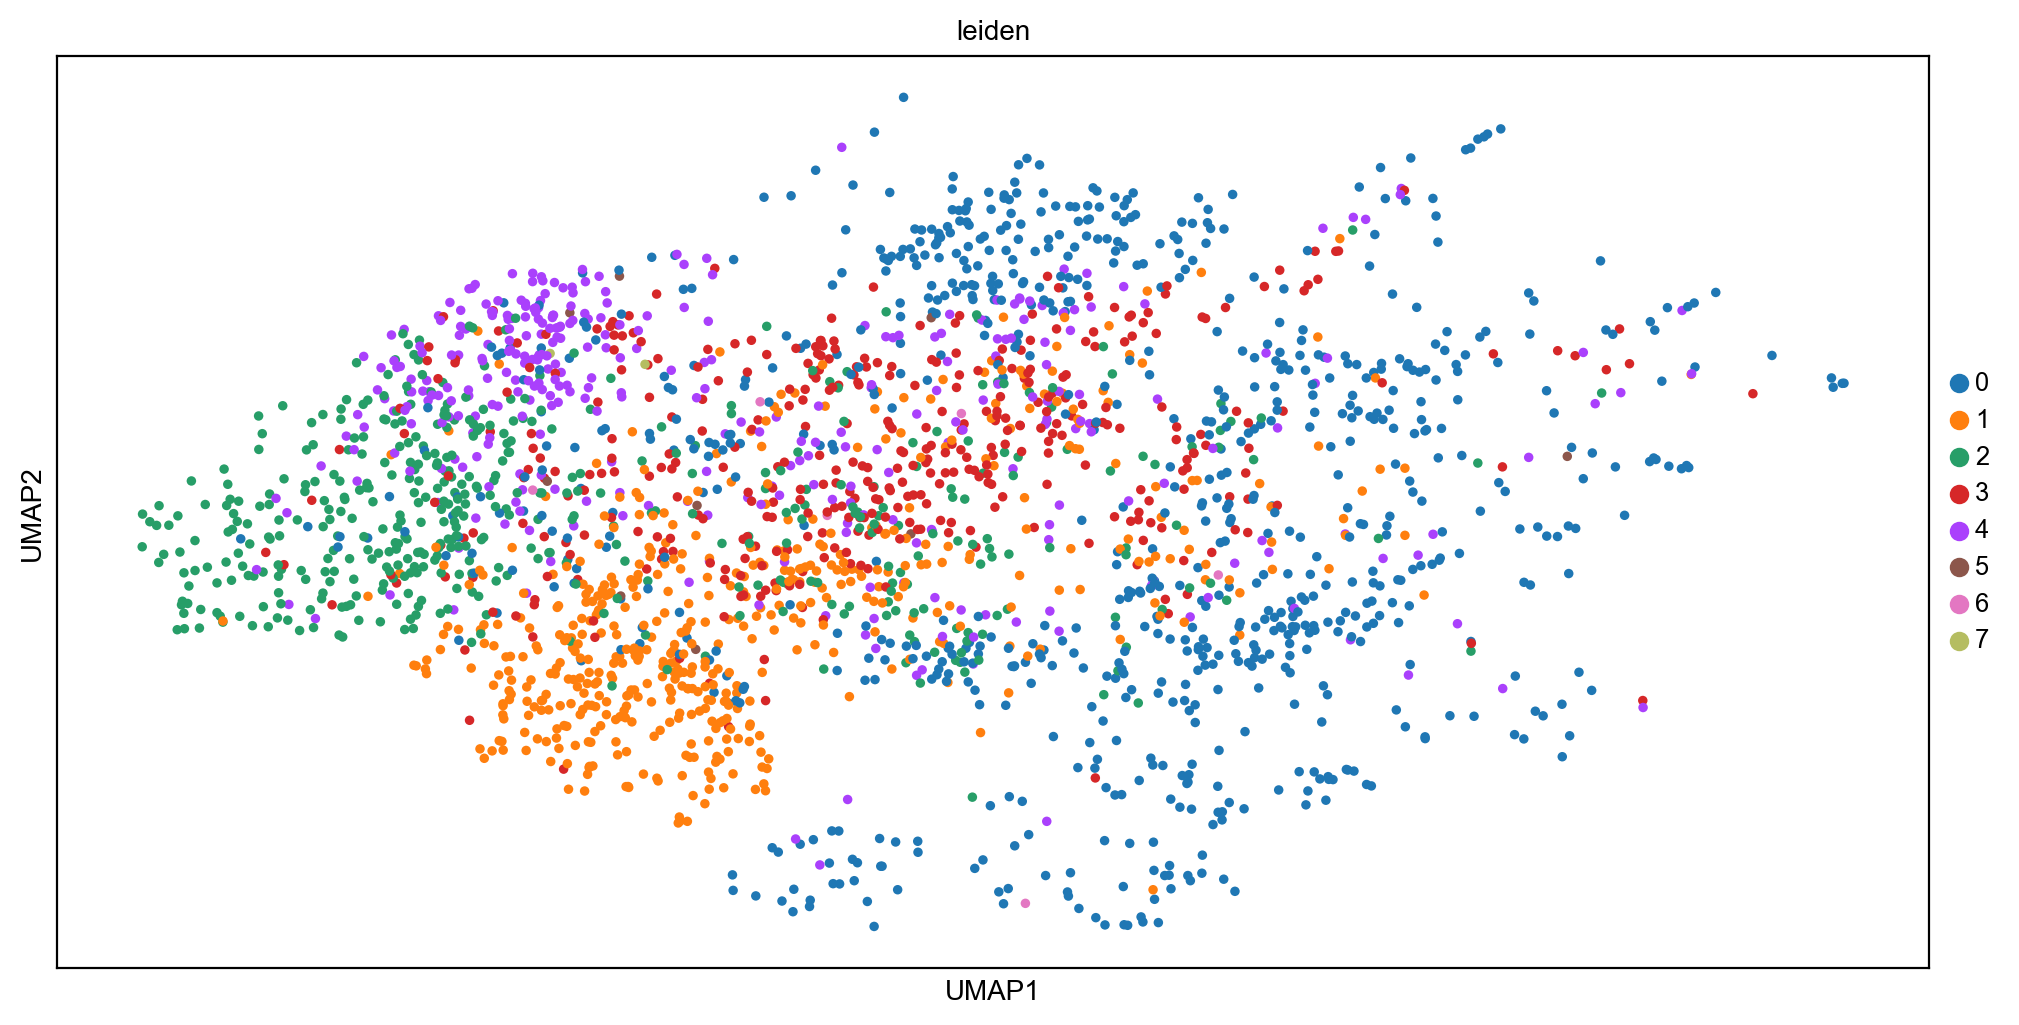

In [14]:
# Plot UMAP
def run_default_scanpy(ann_obj):

    sc.pp.normalize_total(ann_obj) # Norm to median total count
    sc.pp.log1p(ann_obj)
    sc.pp.highly_variable_genes(ann_obj, n_top_genes=2000, flavor="seurat_v3")
    sc.tl.pca(ann_obj, svd_solver='arpack')
    sc.pp.neighbors(ann_obj)
    sc.tl.leiden(ann_obj)
    sc.pl.umap(ann_obj, color=['leiden'])

run_default_scanpy(adata)

2025-01-14 13:51:10,007 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:10,012 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Genes not found in dataset for gene set general_genes: SST, PVALB, VIP, C1QB, OLIG2, PDGRFA
Genes not found in dataset for gene set pfc_features: SST
Generating plots for resolution: default
Plotting gene set general_genes with 21 genes out of 27 provided.


2025-01-14 13:51:10,014 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:10,089 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:10,095 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:10,097 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:10,170 - INFO - Using categorical units to plot a list of strings that are all parsable as 

Plotting gene set pfc_features with 14 genes out of 15 provided.


2025-01-14 13:51:11,999 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:12,005 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:12,007 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:12,078 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-14 13:51:12,084 - INFO - Using categorical units to plot a list of strings that are all parsable as 

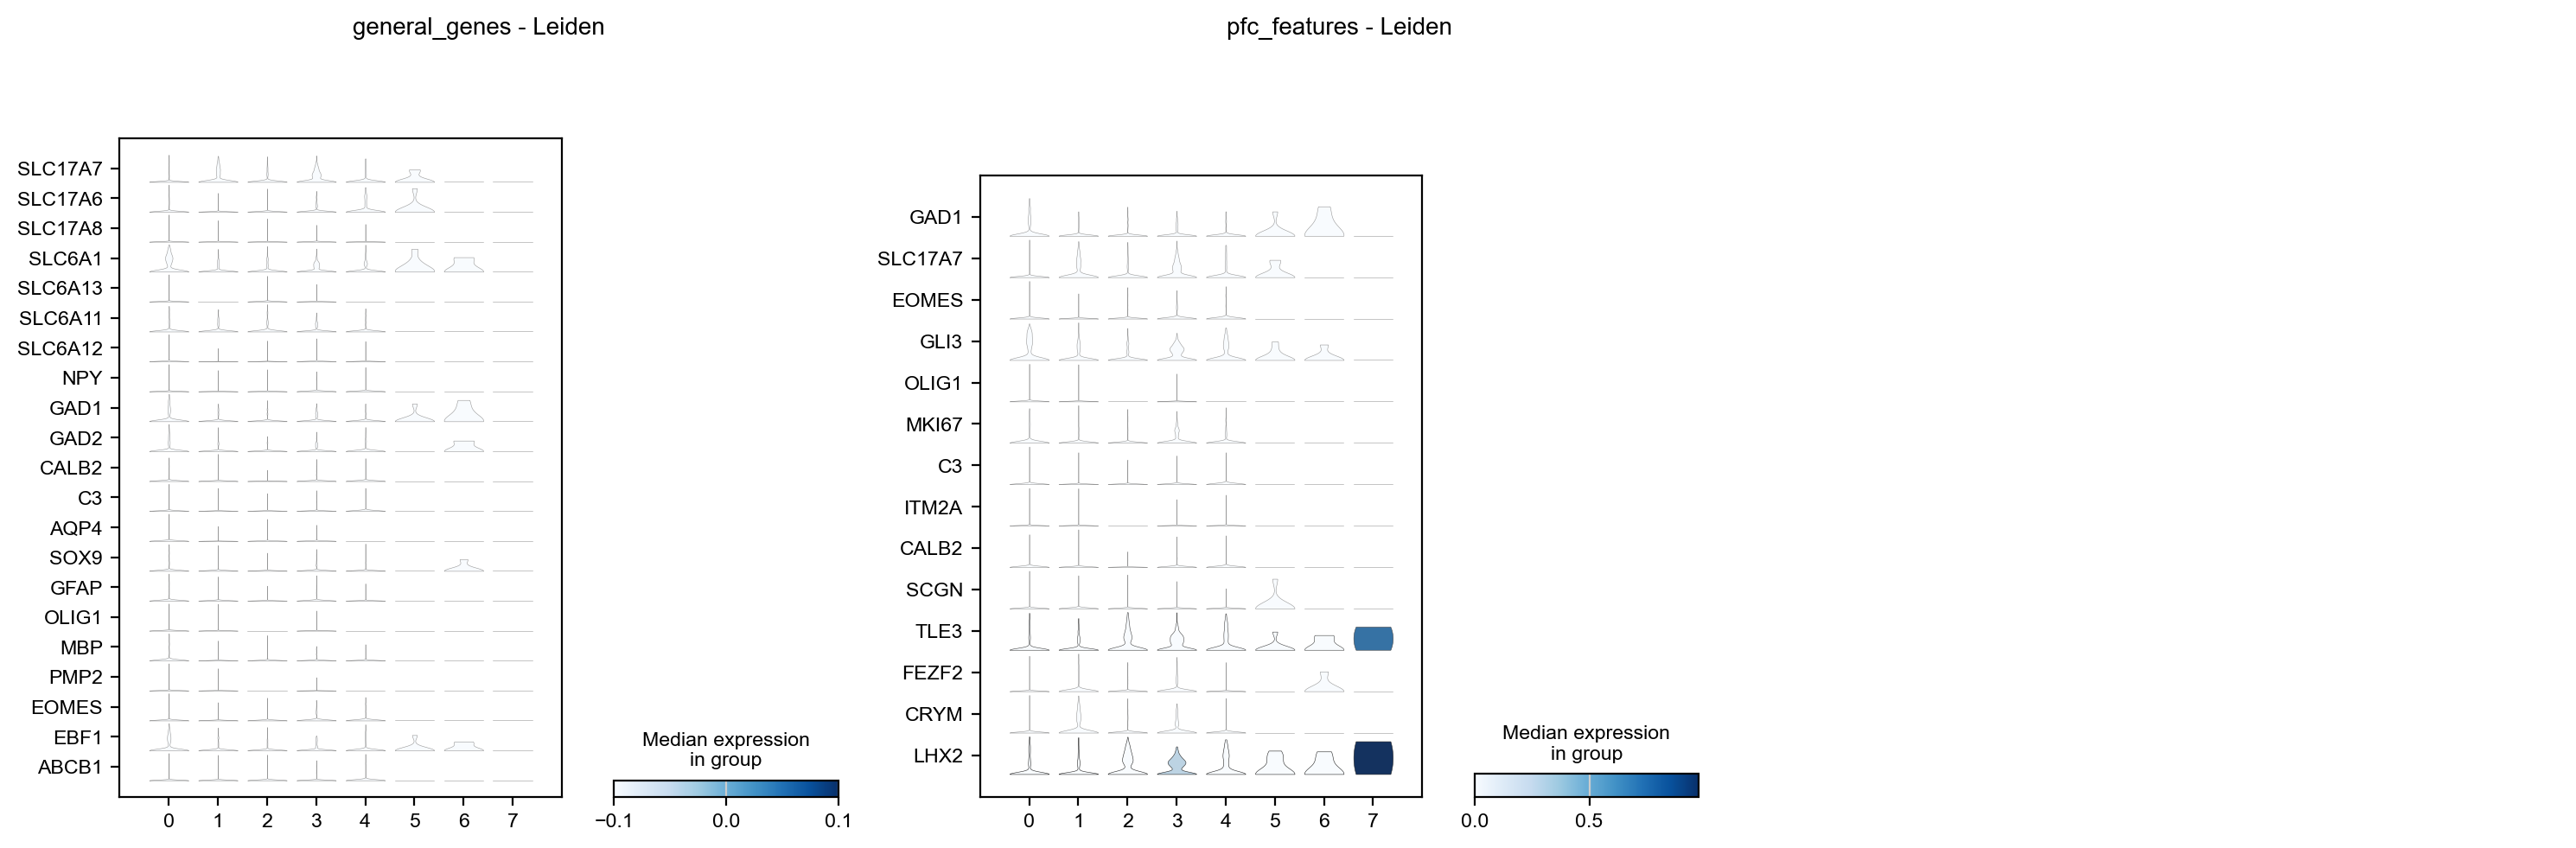

In [15]:
# Plot vlns
gene_sets = [
    ("general_genes", general_genes),
    ("pfc_features", pfc_features)
]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=None, 
    clustering_algorithm="Leiden")
plt.show()  # Display the figure

In [16]:
# Plot sample per cluster
# Function saves an excel file with the cell counts per sample per cluster 
# Extract sample and leiden cluster information from the AnnData object
fig = plot_and_save_cluster_percentages(
    adata=adata,
    output_dir = scanpy_dir,
    clustering_param="leiden"
)
plt.show() 

NameError: name 'os' is not defined

In [ ]:
# Final Dimesnsions
adata.shape

In [ ]:
# Cells per sample after filter
adata.obs['sample'].value_counts()

In [ ]:
# Final distributions per sample
# Create the violin plot
fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.violin(
    adata,
    keys='gene_count',
    jitter=0.4,
    groupby='sample',
    rotation=90,
    size=1.5,
    ax=ax,
    show=False, 
    color='Red'
)
plt.title('Final gene per cell')
plt.axhline(y = 300, color = 'r', linestyle = '-')
plt.axhline(y = 6000, color = 'r', linestyle = '-') 

fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.violin(
    adata,
    keys='total_counts',
    jitter=0.4,
    groupby='sample',
    rotation=90,
    size=1.5,
    ax=ax,
    show=False, 
    color='Red'
)
plt.title('Final counts per cell')
plt.axhline(y = 500, color = 'r', linestyle = '-')